# 1. Import Libraries

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# 2. Load the Datasets

In [8]:
listings  = pd.read_csv('Listings.csv', encoding='latin1')

C:\Users\hp\AppData\Local\Temp\ipykernel_3120\498040556.py:1: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  listings  = pd.read_csv('Listings.csv', encoding='latin1')


In [10]:
reviews  = pd.read_csv('Reviews.csv')

# 3. Understand the Dataset

## Listings

In [12]:
listings.shape

(279712, 33)

In [14]:
listings.head(2)

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [15]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

## Reviews

In [16]:
reviews.shape

(5373143, 4)

In [17]:
reviews.head()

,listing_id,review_id,date,reviewer_id
0,11798,330265172,2018-09-30,11863072
1,15383,330103585,2018-09-30,39147453
2,16455,329985788,2018-09-30,1125378
3,17919,330016899,2018-09-30,172717984
4,26827,329995638,2018-09-30,17542859


In [18]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5373143 entries, 0 to 5373142
Data columns (total 4 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   listing_id   int64 
 1   review_id    int64 
 2   date         object
 3   reviewer_id  int64 
dtypes: int64(3), object(1)
memory usage: 164.0+ MB


In [19]:
print(f"Listings: {listings.shape[0]:,} rows × {listings.shape[1]} columns")
print(f"Reviews : {reviews.shape[0]:,} rows × {reviews.shape[1]} columns")

Listings: 279,712 rows × 33 columns
Reviews : 5,373,143 rows × 4 columns


# 4. Check Duplicate Records

## Listings

In [20]:
print("Duplicate listing rows:", listings.duplicated().sum())
print("Duplicate listing IDs:", listings["listing_id"].duplicated().sum())

Duplicate listing rows: 0
Duplicate listing IDs: 0


## Reviews

In [21]:
print("Duplicate review rows:", reviews.duplicated().sum())
print("Duplicate review IDs:", reviews["review_id"].duplicated().sum())

Duplicate review rows: 0
Duplicate review IDs: 160


####  review_id is not globally unique
#### Validate uniqueness using the composite key:
#### (listing_id, review_id)


In [22]:
print(
    "Duplicate (listing_id, review_id):",
    reviews.duplicated(["listing_id", "review_id"]).sum()
)

Duplicate (listing_id, review_id): 0


# 5. Missing Value Analysis

## Listings

In [23]:
missing_listings = pd.DataFrame({
    "Missing Count": listings.isna().sum(),
    "Missing %": listings.isna().mean() * 100
})

missing_listings = (
    missing_listings
    .sort_values("Missing Count", ascending=False)
)

missing_listings[missing_listings["Missing Count"] > 0]

,Missing Count,Missing %
district,242700,86.767818
host_response_time,128782,46.040928
host_response_rate,128782,46.040928
host_acceptance_rate,113087,40.429799
review_scores_value,91785,32.814109
review_scores_location,91775,32.810534
review_scores_checkin,91771,32.809104
review_scores_accuracy,91713,32.788368
review_scores_communication,91687,32.779073
review_scores_cleanliness,91665,32.771208


## Visualize missing values

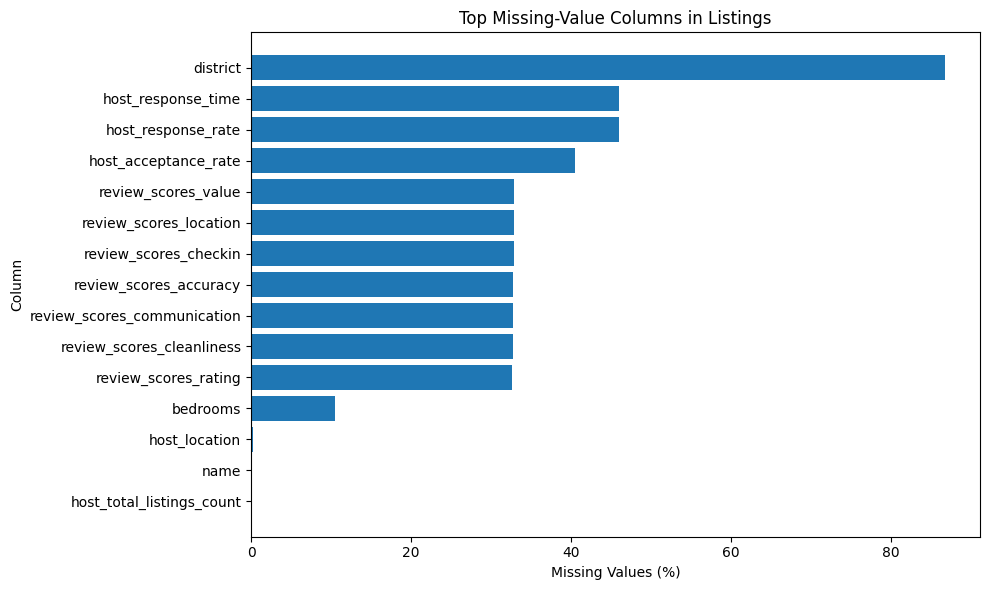

In [26]:
missing_plot = missing_listings[
    missing_listings["Missing Count"] > 0
].head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    missing_plot.index[::-1],
    missing_plot["Missing %"][::-1]
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Column")
plt.title("Top Missing-Value Columns in Listings")

plt.tight_layout()
plt.show()

## Reviews

In [27]:
missing_reviews = pd.DataFrame({
    "Missing Count": reviews.isna().sum(),
    "Missing %": reviews.isna().mean() * 100
})

missing_reviews[missing_reviews["Missing Count"] > 0]

,Missing Count,Missing %


# 6. Listings — Price Analysis

In [28]:
listings["price"] = pd.to_numeric(
    listings["price"]
    .astype(str)
    .str.replace(r"[$,]", "", regex=True),
    errors="coerce"
)

## Descriptive statistics

In [29]:
listings["price"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    279712.000000
mean        608.792737
std        3441.826611
min           0.000000
25%          75.000000
50%         150.000000
75%         474.000000
90%        1200.000000
95%        2000.000000
99%        6500.000000
max      625216.000000
Name: price, dtype: float64

## Check invalid prices

In [30]:
listings[listings["price"] <= 0][
    ["listing_id", "city", "price"]
]

,listing_id,city,price
98209,44312919,Paris,0
202022,42830099,New York,0
202023,43247472,New York,0
203253,43205598,New York,0
203254,44567521,New York,0
...,...,...,...
208940,42534857,Rome,0
208941,43036135,Rome,0
210617,42065564,New York,0
212834,43308777,Paris,0


In [31]:
print("Listings with price <= 0:",
      (listings["price"] <= 0).sum())

Listings with price <= 0: 113


## Price distribution

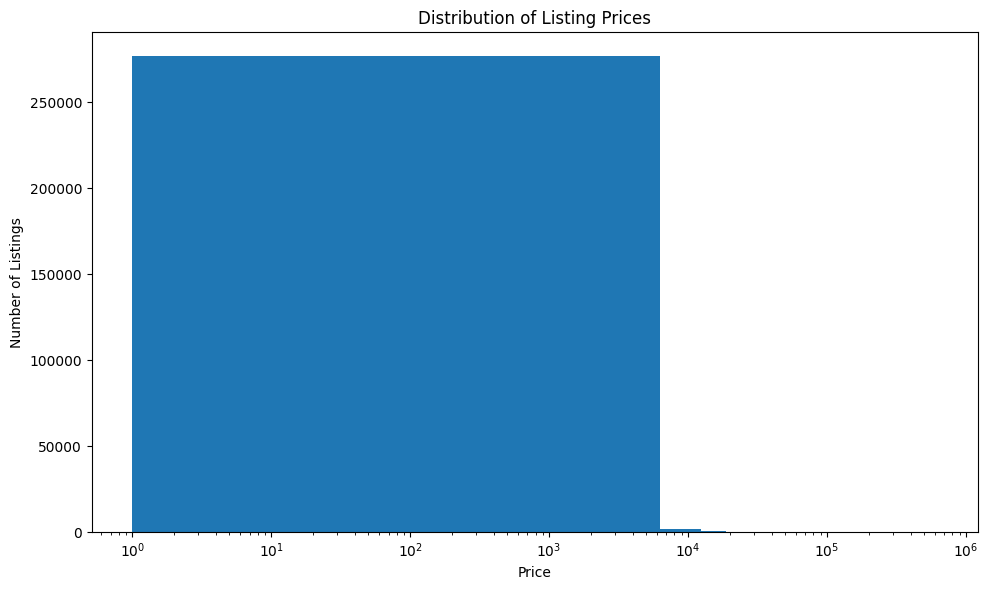

In [32]:
plt.figure(figsize=(10, 6))

plt.hist(
    listings.loc[listings["price"] > 0, "price"],
    bins=100
)

plt.xscale("log")

plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.title("Distribution of Listing Prices")

plt.tight_layout()
plt.show()

## Median vs mean

In [33]:
print("Mean price:", listings["price"].mean())
print("Median price:", listings["price"].median())

Mean price: 608.7927368150097
Median price: 150.0


## 7. Listings by City

In [34]:
city_counts = listings["city"].value_counts()

city_counts

city
Paris             64690
New York          37012
Sydney            33630
Rome              27647
Rio de Janeiro    26615
Istanbul          24519
Mexico City       20065
Bangkok           19361
Cape Town         19086
Hong Kong          7087
Name: count, dtype: int64

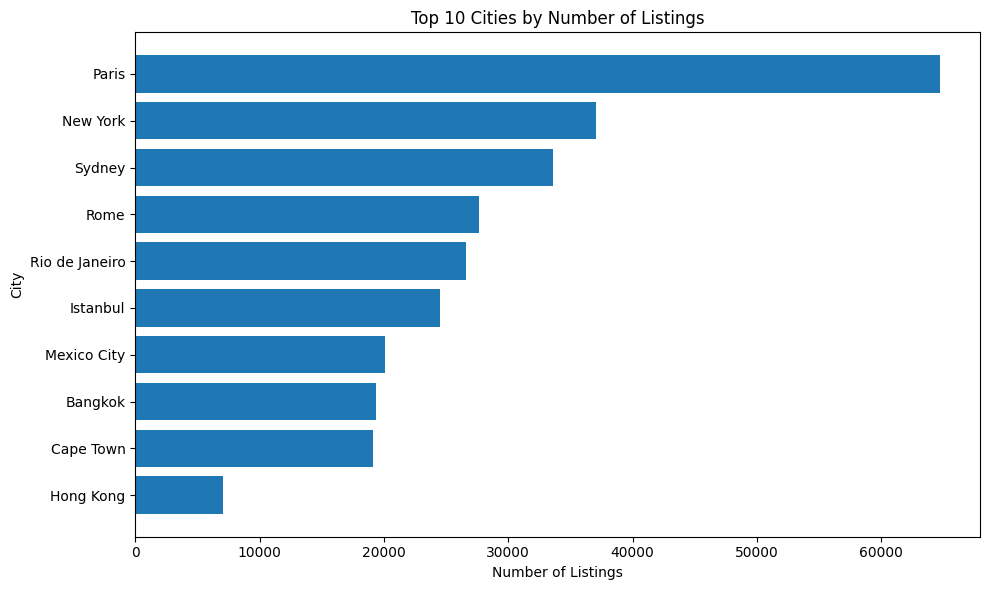

In [35]:
top_cities = city_counts.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_cities.index[::-1],
    top_cities.values[::-1]
)

plt.xlabel("Number of Listings")
plt.ylabel("City")
plt.title("Top 10 Cities by Number of Listings")

plt.tight_layout()
plt.show()

# 8. Room Type Analysis

In [37]:
room_counts = listings["room_type"].value_counts()

room_counts

room_type
Entire place    182005
Private room     86988
Hotel room        5857
Shared room       4862
Name: count, dtype: int64

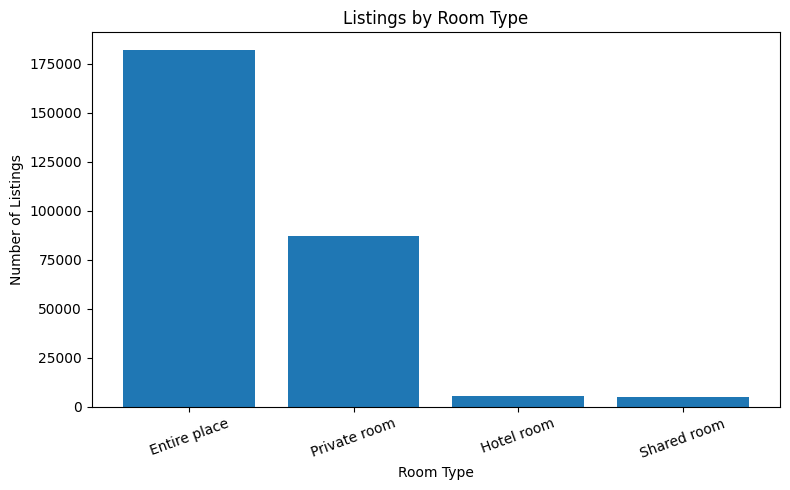

In [38]:
plt.figure(figsize=(8, 5))

plt.bar(
    room_counts.index,
    room_counts.values
)

plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.title("Listings by Room Type")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

# 9. Property Type Analysis

In [39]:
property_counts = listings["property_type"].value_counts()

property_counts.head(20)

property_type
Entire apartment                      138989
Private room in apartment              47322
Private room in house                  13292
Entire house                           13273
Entire condominium                     11250
Room in boutique hotel                  5771
Entire loft                             4587
Private room in condominium             4462
Private room in bed and breakfast       4238
Entire serviced apartment               3973
Room in hotel                           3205
Private room in townhouse               2959
Shared room in apartment                2420
Entire townhouse                        2331
Entire guest suite                      2273
Private room in serviced apartment      1542
Entire villa                            1508
Room in aparthotel                      1495
Private room in guest suite             1370
Private room in guesthouse              1337
Name: count, dtype: int64

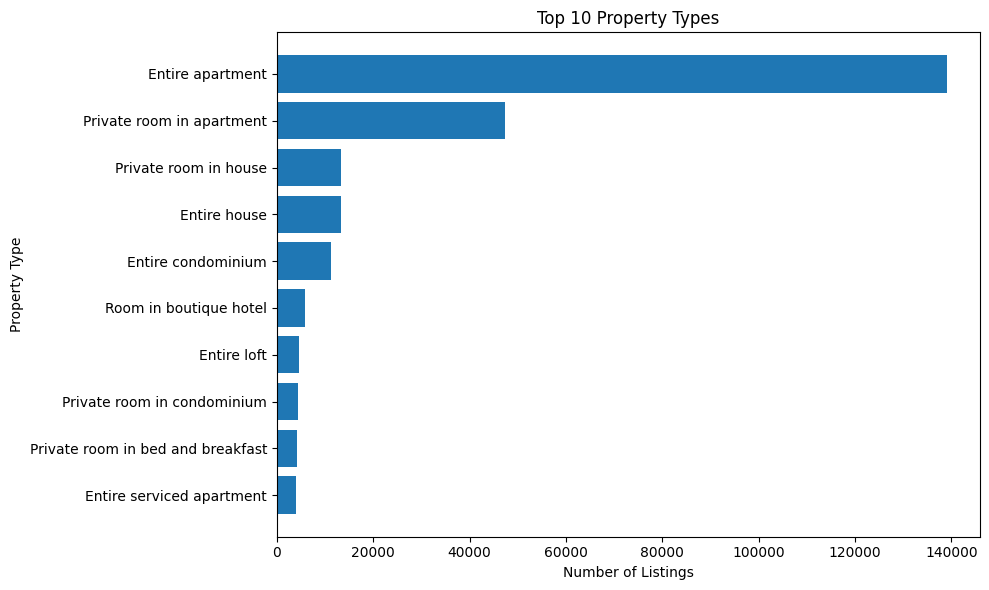

In [40]:
top_properties = property_counts.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_properties.index[::-1],
    top_properties.values[::-1]
)

plt.xlabel("Number of Listings")
plt.ylabel("Property Type")
plt.title("Top 10 Property Types")

plt.tight_layout()
plt.show()

# 10. Accommodation Analysis

## Accommodates

In [41]:
listings["accommodates"].describe()

count    279712.000000
mean          3.288736
std           2.133379
min           0.000000
25%           2.000000
50%           2.000000
75%           4.000000
max          16.000000
Name: accommodates, dtype: float64

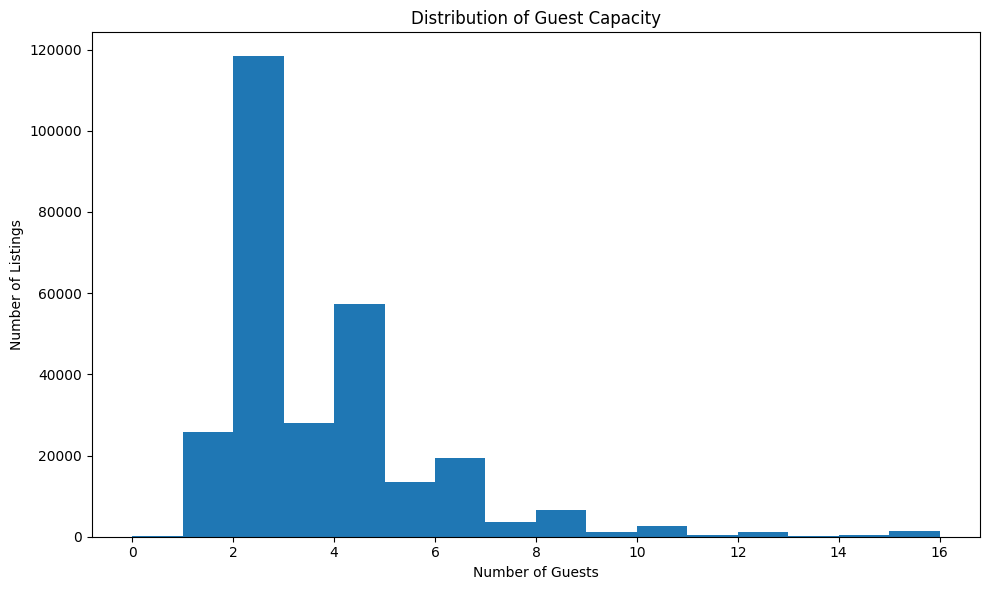

In [42]:
plt.figure(figsize=(10, 6))

plt.hist(
    listings["accommodates"],
    bins=16
)

plt.xlabel("Number of Guests")
plt.ylabel("Number of Listings")
plt.title("Distribution of Guest Capacity")

plt.tight_layout()
plt.show()

## Bedrooms

In [43]:
listings["bedrooms"].describe()

count    250277.000000
mean          1.515509
std           1.153080
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          50.000000
Name: bedrooms, dtype: float64

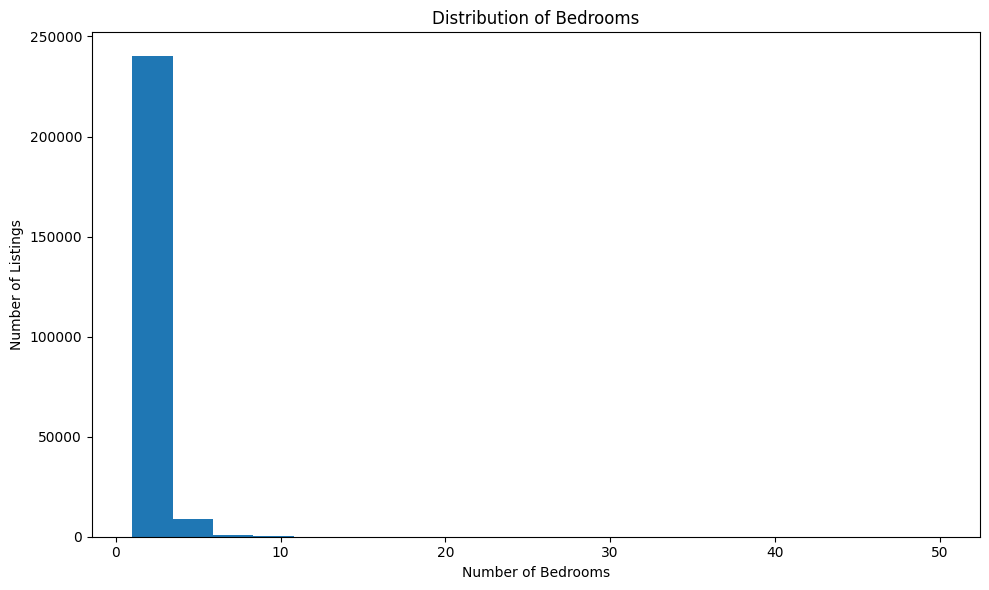

In [44]:
plt.figure(figsize=(10, 6))

plt.hist(
    listings["bedrooms"].dropna(),
    bins=20
)

plt.xlabel("Number of Bedrooms")
plt.ylabel("Number of Listings")
plt.title("Distribution of Bedrooms")

plt.tight_layout()
plt.show()

# 11. Minimum Nights Analysis

In [45]:
listings["minimum_nights"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    279712.000000
mean          8.050967
std          31.518946
min           1.000000
25%           1.000000
50%           2.000000
75%           5.000000
90%          30.000000
95%          30.000000
99%          80.000000
max        9999.000000
Name: minimum_nights, dtype: float64

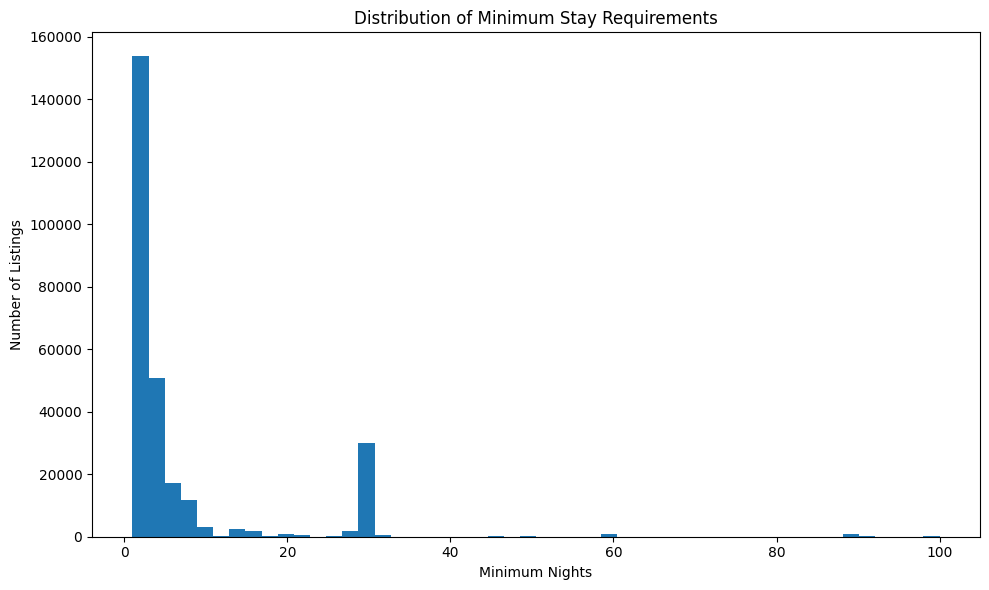

In [46]:
plt.figure(figsize=(10, 6))

plt.hist(
    listings.loc[listings["minimum_nights"] <= 100, "minimum_nights"],
    bins=50
)

plt.xlabel("Minimum Nights")
plt.ylabel("Number of Listings")
plt.title("Distribution of Minimum Stay Requirements")

plt.tight_layout()
plt.show()

In [47]:
listings.nlargest(
    20,
    "minimum_nights"
)[
    ["listing_id", "city", "minimum_nights"]
]

,listing_id,city,minimum_nights
180165,8179304,Paris,9999
255298,4204302,New York,1250
11492,34028716,Paris,1125
89314,20010285,Sydney,1125
91187,36923173,Sydney,1125
5316,24868060,Paris,1124
80504,38487619,Cape Town,1124
112525,2942732,New York,1124
177550,41989834,Sydney,1123
89324,5579404,Paris,1112


# 12. Review Score Analysis

In [48]:
score_columns = [
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value"
]

listings[score_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
review_scores_rating,188307.0,93.405195,10.070437,20.0,91.0,96.0,100.0,100.0
review_scores_accuracy,187999.0,9.565476,0.990878,2.0,9.0,10.0,10.0,10.0
review_scores_cleanliness,188047.0,9.312869,1.146072,2.0,9.0,10.0,10.0,10.0
review_scores_checkin,187941.0,9.701534,0.867434,2.0,10.0,10.0,10.0,10.0
review_scores_communication,188025.0,9.698593,0.886884,2.0,10.0,10.0,10.0,10.0
review_scores_location,187937.0,9.633994,0.833234,2.0,9.0,10.0,10.0,10.0
review_scores_value,187927.0,9.335364,1.042625,2.0,9.0,10.0,10.0,10.0


## Rating distribution

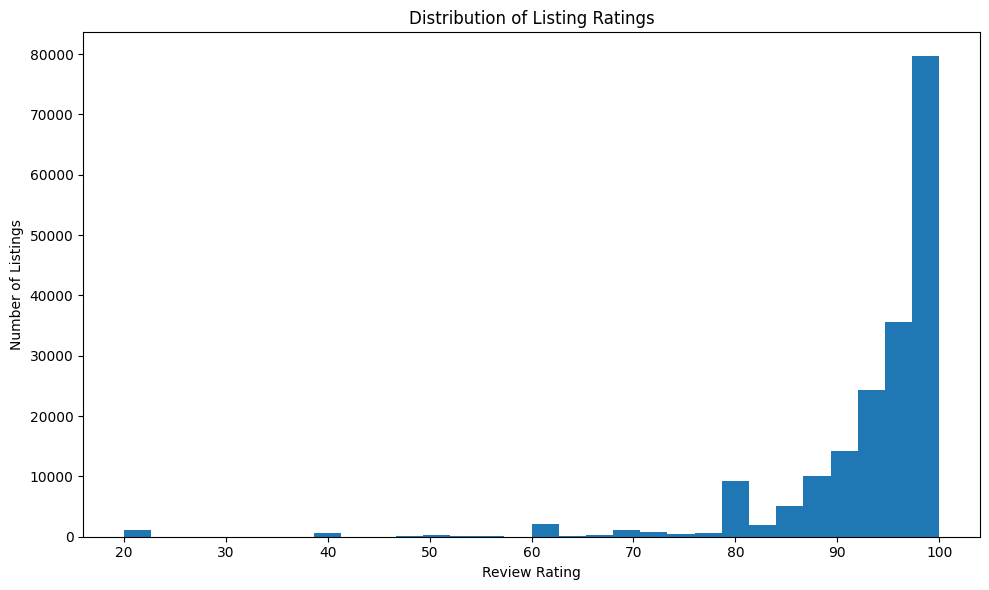

In [49]:
plt.figure(figsize=(10, 6))

plt.hist(
    listings["review_scores_rating"].dropna(),
    bins=30
)

plt.xlabel("Review Rating")
plt.ylabel("Number of Listings")
plt.title("Distribution of Listing Ratings")

plt.tight_layout()
plt.show()

# 13. Host Analysis

## Superhost distribution

In [50]:
listings["host_is_superhost"].value_counts(dropna=False)

host_is_superhost
f      229294
t       50253
NaN       165
Name: count, dtype: int64

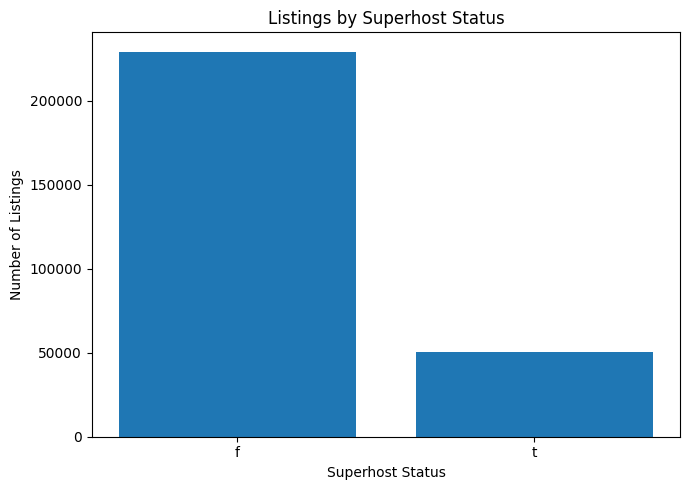

In [51]:
superhost_counts = listings["host_is_superhost"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    superhost_counts.index.astype(str),
    superhost_counts.values
)

plt.xlabel("Superhost Status")
plt.ylabel("Number of Listings")
plt.title("Listings by Superhost Status")

plt.tight_layout()
plt.show()

## Host portfolio size

In [53]:
listings["host_total_listings_count"].describe()

count    279547.000000
mean         24.581612
std         284.041143
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max        7235.000000
Name: host_total_listings_count, dtype: float64

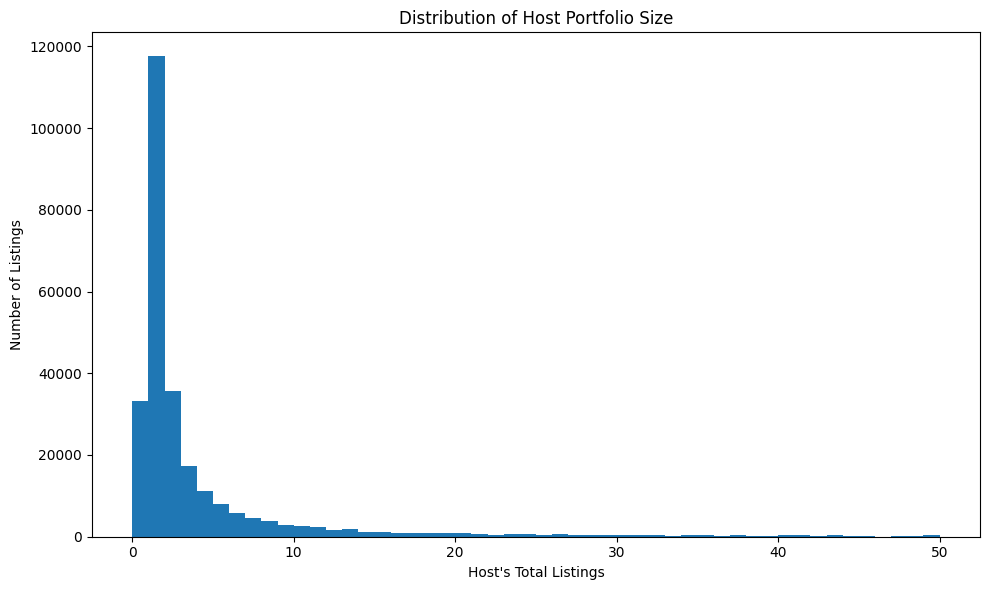

In [54]:
plt.figure(figsize=(10, 6))

plt.hist(
    listings.loc[
        listings["host_total_listings_count"] <= 50,
        "host_total_listings_count"
    ].dropna(),
    bins=50
)

plt.xlabel("Host's Total Listings")
plt.ylabel("Number of Listings")
plt.title("Distribution of Host Portfolio Size")

plt.tight_layout()
plt.show()

# 14. Reviews EDA

## Reviews over time

In [55]:
reviews["date"] = pd.to_datetime(reviews["date"])

In [56]:
reviews["year"] = reviews["date"].dt.year

In [57]:
reviews_by_year = reviews["year"].value_counts().sort_index()

reviews_by_year

year
2008          2
2009        115
2010       1236
2011       6253
2012      19922
2013      50522
2014     122132
2015     280332
2016     501754
2017     777200
2018    1142496
2019    1633546
2020     755324
2021      82309
Name: count, dtype: int64

## Visualization

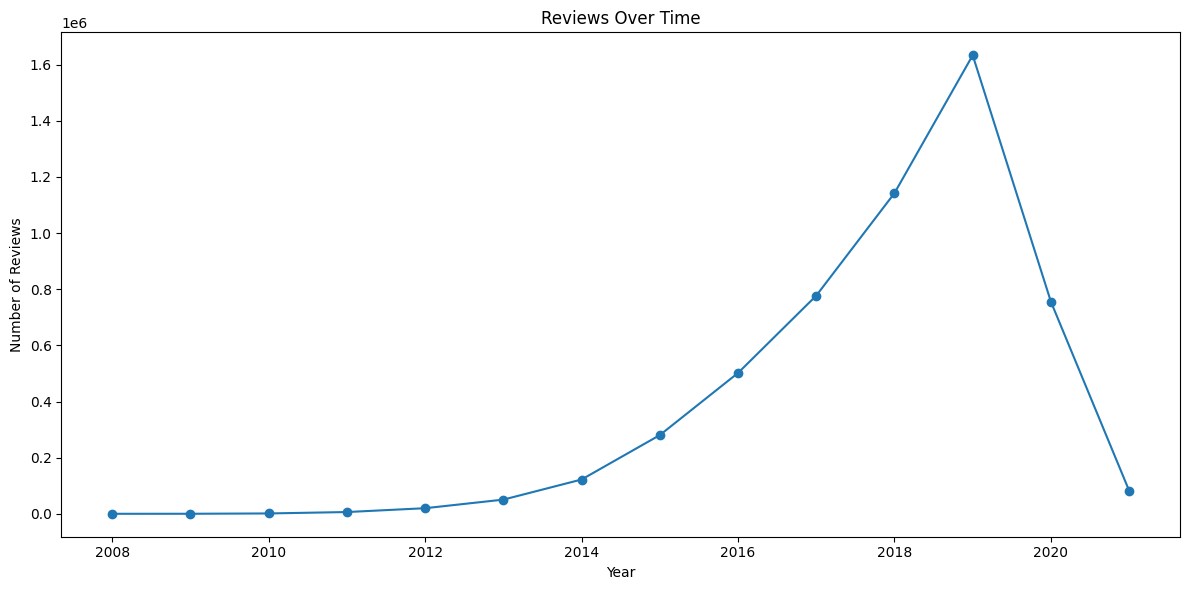

In [58]:
plt.figure(figsize=(12, 6))

plt.plot(
    reviews_by_year.index,
    reviews_by_year.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.title("Reviews Over Time")

plt.tight_layout()
plt.show()

# 15. Reviews per Listing

In [59]:
reviews_per_listing = (
    reviews
    .groupby("listing_id")
    .size()
    .sort_values(ascending=False)
)

reviews_per_listing.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    193556.000000
mean         27.760147
std          49.877684
min           1.000000
25%           2.000000
50%           8.000000
75%          29.000000
90%          78.000000
95%         125.000000
99%         246.450000
max         891.000000
dtype: float64

## Most reviewed listings

In [60]:
reviews_per_listing.head(20)

listing_id
17222007    891
8637229     828
1249964     796
32011332    762
2399029     754
32678719    753
470817      717
24745583    710
865289      702
162163      700
28323996    685
2709785     684
8228690     676
1385250     672
7944819     671
825299      670
747656      663
31077175    661
898906      657
1373696     654
dtype: int64

# 16. Listings With and Without Reviews

In [61]:
reviewed_listing_ids = reviews["listing_id"].unique()

listings["has_reviews"] = listings["listing_id"].isin(
    reviewed_listing_ids
)

In [62]:
listings["has_reviews"].value_counts()

has_reviews
True     193556
False     86156
Name: count, dtype: int64

Calculate percentages

In [63]:
review_status = (
    listings["has_reviews"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

review_status

has_reviews
True     69.2
False    30.8
Name: proportion, dtype: float64

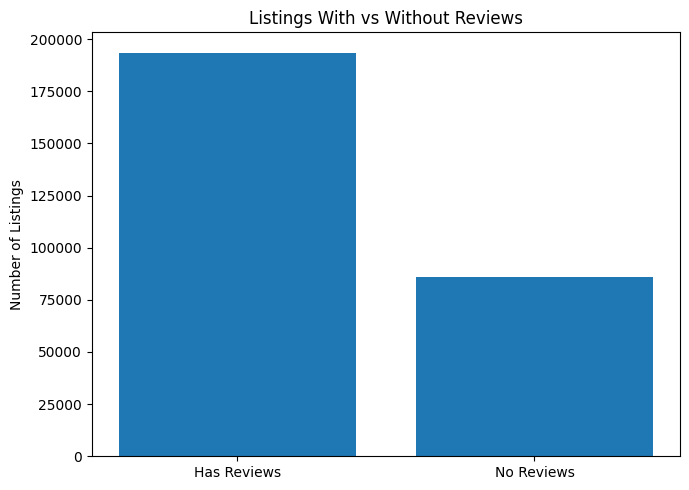

In [65]:
review_counts = listings["has_reviews"].value_counts()

labels = ["Has Reviews", "No Reviews"]

plt.figure(figsize=(7, 5))

plt.bar(
    labels,
    [
        review_counts.get(True, 0),
        review_counts.get(False, 0)
    ]
)

plt.ylabel("Number of Listings")
plt.title("Listings With vs Without Reviews")

plt.tight_layout()
plt.show()

# 17. Review Coverage by City

In [66]:
city_review = (
    listings
    .groupby("city")
    .agg(
        total_listings=("listing_id", "count"),
        listings_with_reviews=("has_reviews", "sum")
    )
)

city_review["review_coverage_pct"] = (
    city_review["listings_with_reviews"]
    / city_review["total_listings"]
    * 100
)

city_review = city_review.sort_values(
    "review_coverage_pct",
    ascending=False
)

city_review

,total_listings,listings_with_reviews,review_coverage_pct
city,,,
Rome,27647,21205,76.699099
Paris,64690,49228,76.098315
New York,37012,27489,74.270507
Mexico City,20065,14679,73.157239
Cape Town,19086,13718,71.874673
Sydney,33630,23599,70.172465
Rio de Janeiro,26615,16657,62.585008
Bangkok,19361,11440,59.087857
Hong Kong,7087,3868,54.578806


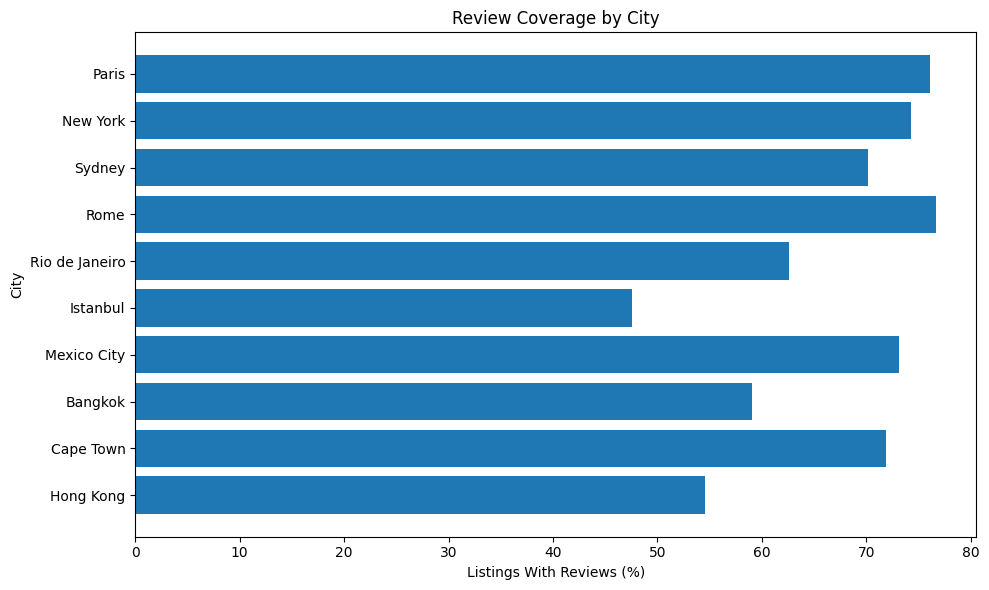

In [67]:
top_city_coverage = city_review.sort_values(
    "total_listings",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_city_coverage.index[::-1],
    top_city_coverage["review_coverage_pct"][::-1]
)

plt.xlabel("Listings With Reviews (%)")
plt.ylabel("City")
plt.title("Review Coverage by City")

plt.tight_layout()
plt.show()

# 18. Listings + Reviews Relationship Check

## Orphan reviews

In [68]:
orphan_reviews = reviews[
    ~reviews["listing_id"].isin(listings["listing_id"])
]

print("Orphan review rows:", len(orphan_reviews))

Orphan review rows: 0


## Composite key validation

In [69]:
print(
    "Duplicate (listing_id, review_id):",
    reviews.duplicated(
        ["listing_id", "review_id"]
    ).sum()
)

Duplicate (listing_id, review_id): 0


# 19. EDA Summary

## EDA Summary

### Listings
- The Listings dataset contains 279,712 listings across 33 columns.
- Listing prices are highly right-skewed, with a large difference between the mean and median.
- Entire-place listings represent the largest room-type category.
- Paris has the highest number of listings in the dataset.
- Several listing attributes contain substantial missing values, particularly district, host response information, and review scores.
- Minimum and maximum stay requirements contain extreme values that require treatment before modeling.

### Reviews
- The Reviews dataset contains 5,373,143 reviews across 4 columns.
- There are no duplicate `(listing_id, review_id)` combinations.
- Review IDs are not globally unique and therefore should not be treated as a standalone primary key.
- Reviews are concentrated among a subset of listings.
- Review activity increased substantially over time before declining in the final period of the dataset.

### Data Preparation Implications
- Missing values need to be handled before clustering.
- Highly skewed variables such as price, minimum nights, review counts, and host portfolio size require appropriate transformation or normalization before modeling.
- Extreme price observations require treatment.
- Because listing prices are expressed in local currencies across cities, raw price should not be directly compared across cities.
- These findings provide the basis for the subsequent SQL analysis and K-Means segmentation.